# Otimização de Investimentos: Exemplo Prático

## Cenário do Problema

Você é um gestor de investimentos com R$ 100.000 para alocar entre três opções:

- **Investimento A**: 5% de retorno (baixo risco - ex: títulos do governo)
- **Investimento B**: 10% de retorno (risco médio - ex: fundos de renda fixa)
- **Investimento C**: 12% de retorno (alto risco - ex: ações de crescimento)

### Por que existem limites nos investimentos?

- **Limite em B (20%)**: Regulamentação ou política de diversificação
- **Limite em C (10%)**: Gestão de risco - investimentos de alto retorno geralmente têm maior volatilidade

**Objetivo**: Maximizar o retorno total respeitando os limites de risco.

In [1]:
# Execute esta célula primeiro no Google Colab para instalar as dependências
!pip install -q pyomo highspy
print("Dependências instaladas com sucesso!")

Dependências instaladas com sucesso!


In [2]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 1. Estratégia "Ingênua" — Testando Nossa Intuição

Antes de usar otimização, vamos pensar: **qual seria a alocação mais razoável?**

Estratégia intuitiva: investir o máximo possível nos ativos de maior retorno (C e B), e o restante em A.

In [3]:
# Estratégia ingênua: investir tudo no ativo de maior retorno?
capital_total = 100000
limite_C = 0.1 * capital_total  # Máximo 10% em C

print("=== ESTRATÉGIA INGÊNUA: 'Tudo no investimento de maior retorno' ===")
print(f"Queremos investir tudo (R$ {capital_total:,.2f}) em C (12% retorno)")
print(f"Mas o limite de C é apenas R$ {limite_C:,.2f}")
print("Estratégia impossível devido às restrições de risco!")
print()
print("Vamos então tentar algo mais razoável...")

=== ESTRATÉGIA INGÊNUA: 'Tudo no investimento de maior retorno' ===
Queremos investir tudo (R$ 100,000.00) em C (12% retorno)
Mas o limite de C é apenas R$ 10,000.00
Estratégia impossível devido às restrições de risco!

Vamos então tentar algo mais razoável...


In [4]:
# Estratégia ingênua melhorada: usar os limites máximos de B e C, resto em A
investimento_C_ingenuo = 10000   # 10% do capital (máximo permitido)
investimento_B_ingenuo = 20000   # 20% do capital (máximo permitido)
investimento_A_ingenuo = capital_total - investimento_B_ingenuo - investimento_C_ingenuo

retorno_A_ingenuo = 0.05 * investimento_A_ingenuo
retorno_B_ingenuo = 0.10 * investimento_B_ingenuo
retorno_C_ingenuo = 0.12 * investimento_C_ingenuo
retorno_total_ingenuo = retorno_A_ingenuo + retorno_B_ingenuo + retorno_C_ingenuo

print("=== ESTRATÉGIA INGÊNUA: 'Máximo em B e C, resto em A' ===")
print(f"A: R$ {investimento_A_ingenuo:,.2f} -> Retorno: R$ {retorno_A_ingenuo:,.2f}")
print(f"B: R$ {investimento_B_ingenuo:,.2f} -> Retorno: R$ {retorno_B_ingenuo:,.2f}")
print(f"C: R$ {investimento_C_ingenuo:,.2f} -> Retorno: R$ {retorno_C_ingenuo:,.2f}")
print(f"\nRetorno Total: R$ {retorno_total_ingenuo:,.2f}")
print()
print("Parece razoável! Mas será que é realmente o melhor possível?")
print("A otimização matemática nos dá a CERTEZA — vamos verificar.")

=== ESTRATÉGIA INGÊNUA: 'Máximo em B e C, resto em A' ===
A: R$ 70,000.00 -> Retorno: R$ 3,500.00
B: R$ 20,000.00 -> Retorno: R$ 2,000.00
C: R$ 10,000.00 -> Retorno: R$ 1,200.00

Retorno Total: R$ 6,700.00

Parece razoável! Mas será que é realmente o melhor possível?
A otimização matemática nos dá a CERTEZA — vamos verificar.


## 2. Modelagem e Solução Otimizada

Agora vamos usar o **Pyomo** para modelar o problema formalmente e resolver com o solver **HiGHS**.

A grande vantagem da otimização: ela nos **garante matematicamente** que a solução encontrada é a melhor possível.

In [5]:
def criar_modelo_investimento(capital=100000, retorno_A=0.05, retorno_B=0.10, retorno_C=0.12,
                               limite_B_percent=0.2, limite_C_percent=0.1):
    """Cria o modelo de otimização de investimentos.

    Os retornos e limites são parametrizados para permitir reutilizar esta
    mesma função na análise de sensibilidade (secão 5), sem duplicar o modelo.
    """
    m = pyo.ConcreteModel()

    # --- Conjuntos ---
    m.setInv = pyo.Set(initialize=['A', 'B', 'C'])

    # --- Parâmetros ---
    m.Capital = capital

    # --- Variáveis de Decisão ---
    m.C = pyo.Var(m.setInv, bounds=(0, None))
    m.R = pyo.Var(m.setInv, bounds=(0, None))

    # --- Função Objetivo ---
    m.obj = pyo.Objective(expr=pyo.summation(m.R), sense=pyo.maximize)

    # --- Restrições ---
    m.C1 = pyo.Constraint(expr=pyo.summation(m.C) == m.Capital)
    m.C2 = pyo.Constraint(expr=m.R['A'] == retorno_A * m.C['A'])
    m.C3 = pyo.Constraint(expr=m.R['B'] == retorno_B * m.C['B'])
    m.C4 = pyo.Constraint(expr=m.R['C'] == retorno_C * m.C['C'])
    m.C5 = pyo.Constraint(expr=m.C['B'] <= limite_B_percent * m.Capital)
    m.C6 = pyo.Constraint(expr=m.C['C'] <= limite_C_percent * m.Capital)

    return m

In [6]:
def resolver_modelo(modelo, nome_solver='appsi_highs'):
    """
    Resolve o modelo usando o solver especificado.
    'appsi_highs' é instalado via pip (highspy) e não exige nenhum executável
    de sistema, o que o torna a opção mais confiável em Colab/CI.
    """
    try:
        opt = SolverFactory(nome_solver)
        resultado = opt.solve(modelo, tee=False) # tee=True para ver os logs do solver
        return resultado
    except Exception as e:
        print(f"\n[ERRO] Falha ao executar o solver '{nome_solver}'.")
        print("Verifique se ele está instalado corretamente no ambiente.")
        raise e

In [7]:
# 1. Criação
capital_inicial = 100000
modelo = criar_modelo_investimento(capital=capital_inicial)

# 2. Resolução (HiGHS, instalado via pip — sem dependência de executável externo)
resultado = resolver_modelo(modelo, nome_solver='appsi_highs')

# 3. Análise de Resultados
print("=== RESULTADOS DA OTIMIZAÇÃO ===")
if str(resultado.solver.termination_condition) == "optimal":
    print(f"Status: Solução Ótima Encontrada!\n")
    print("Alocação de Capital:")
    for inv in modelo.setInv:
        valor_investido = pyo.value(modelo.C[inv])
        retorno_obtido = pyo.value(modelo.R[inv])
        print(f" Ativo {inv}: Investiu R$ {valor_investido:,.2f} -> Retorno: R$ {retorno_obtido:,.2f}")
    
    print(f"\nRetorno Total Maximizado: R$ {pyo.value(modelo.obj):,.2f}")
else:
    print(f"O solver não encontrou uma solução ótima. Status: {resultado.solver.termination_condition}")

=== RESULTADOS DA OTIMIZAÇÃO ===
Status: Solução Ótima Encontrada!

Alocação de Capital:
 Ativo A: Investiu R$ 70,000.00 -> Retorno: R$ 3,500.00
 Ativo B: Investiu R$ 20,000.00 -> Retorno: R$ 2,000.00
 Ativo C: Investiu R$ 10,000.00 -> Retorno: R$ 1,200.00

Retorno Total Maximizado: R$ 6,700.00


In [8]:
# Exibir o modelo matemático completo
print("=== MODELO MATEMATICO COMPLETO ===")
modelo.pprint()

=== MODELO MATEMATICO COMPLETO ===
1 Set Declarations
    setInv : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {'A', 'B', 'C'}

2 Var Declarations
    C : Size=3, Index=setInv
        Key : Lower : Value   : Upper : Fixed : Stale : Domain
          A :     0 : 70000.0 :  None : False : False :  Reals
          B :     0 : 20000.0 :  None : False : False :  Reals
          C :     0 : 10000.0 :  None : False : False :  Reals
    R : Size=3, Index=setInv
        Key : Lower : Value  : Upper : Fixed : Stale : Domain
          A :     0 : 3500.0 :  None : False : False :  Reals
          B :     0 : 2000.0 :  None : False : False :  Reals
          C :     0 : 1200.0 :  None : False : False :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : R[A] + R[B] + R[C]

6 Constraint Declarations
    C1 : Size=1, Ind

In [9]:
# Exibir a solução otimizada
investimentos = ['A', 'B', 'C']
alocacoes_otimizadas = [pyo.value(modelo.C[i]) for i in investimentos]
retornos_otimizados = [pyo.value(modelo.R[i]) for i in investimentos]
retorno_total_otimizado = pyo.value(modelo.obj)

print('=== SOLUCAO OTIMIZADA ===')
print(f'Retorno Total (Funcao Objetivo): R$ {retorno_total_otimizado:,.2f}')
print()
print('Alocacao por investimento:')
for i, inv in enumerate(investimentos):
    print(f"  {inv}: R$ {alocacoes_otimizadas[i]:,.2f} -> Retorno: R$ {retornos_otimizados[i]:,.2f}")

=== SOLUCAO OTIMIZADA ===
Retorno Total (Funcao Objetivo): R$ 6,700.00

Alocacao por investimento:
  A: R$ 70,000.00 -> Retorno: R$ 3,500.00
  B: R$ 20,000.00 -> Retorno: R$ 2,000.00
  C: R$ 10,000.00 -> Retorno: R$ 1,200.00


## 3. Comparação: Intuição vs. Otimização

Vamos comparar nossa estratégia intuitiva com a solução do solver.

In [10]:
# Tabela comparativa
comparacao = pd.DataFrame({
    'Investimento': ['A', 'B', 'C', 'TOTAL'],
    'Estrategia Intuitiva (R$)': [
        investimento_A_ingenuo, investimento_B_ingenuo,
        investimento_C_ingenuo, capital_total
    ],
    'Solucao Otimizada (R$)': alocacoes_otimizadas + [capital_total],
    'Diferenca (R$)': [
        alocacoes_otimizadas[0] - investimento_A_ingenuo,
        alocacoes_otimizadas[1] - investimento_B_ingenuo,
        alocacoes_otimizadas[2] - investimento_C_ingenuo,
        0
    ]
})

print("=== COMPARACAO DE ESTRATEGIAS ===")
print(comparacao.to_string(index=False, float_format='%.2f'))

ganho_otimizacao = retorno_total_otimizado - retorno_total_ingenuo

print(f"\nRetorno Estrategia Intuitiva:  R$ {retorno_total_ingenuo:,.2f}")
print(f"Retorno Solucao Otimizada:     R$ {retorno_total_otimizado:,.2f}")
print(f"Diferenca:                     R$ {ganho_otimizacao:,.2f}")

print()
if abs(ganho_otimizacao) < 0.01:
    print("RESULTADO: As duas estrategias chegaram ao MESMO resultado!")
    print()
    print("Isso acontece porque este problema e simples o suficiente")
    print("para que a intuicao acerte. Mas ha uma diferenca crucial:")
    print()
    print("  -> A intuicao nos diz 'parece bom'.")
    print("  -> A otimizacao nos da CERTEZA MATEMATICA de que")
    print("     nao existe nenhuma solucao melhor.")
    print()
    print("Em problemas mais complexos (dezenas de variaveis,")
    print("restricoes nao obvias), a intuicao falha — e a otimizacao")
    print("se torna indispensavel.")
else:
    percentual = (ganho_otimizacao / retorno_total_ingenuo) * 100
    print(f"A otimizacao encontrou uma solucao melhor: {percentual:.1f}% a mais!")

=== COMPARACAO DE ESTRATEGIAS ===
Investimento  Estrategia Intuitiva (R$)  Solucao Otimizada (R$)  Diferenca (R$)
           A                      70000                70000.00            0.00
           B                      20000                20000.00            0.00
           C                      10000                10000.00            0.00
       TOTAL                     100000               100000.00            0.00

Retorno Estrategia Intuitiva:  R$ 6,700.00
Retorno Solucao Otimizada:     R$ 6,700.00
Diferenca:                     R$ 0.00

RESULTADO: As duas estrategias chegaram ao MESMO resultado!

Isso acontece porque este problema e simples o suficiente
para que a intuicao acerte. Mas ha uma diferenca crucial:

  -> A intuicao nos diz 'parece bom'.
  -> A otimizacao nos da CERTEZA MATEMATICA de que
     nao existe nenhuma solucao melhor.

Em problemas mais complexos (dezenas de variaveis,
restricoes nao obvias), a intuicao falha — e a otimizacao
se torna indispensavel

## 4. Respondendo à Pergunta: "Por que A recebeu mais capital?"

In [11]:
print("=== ANALISE: POR QUE O INVESTIMENTO A RECEBEU MAIS CAPITAL? ===")
print()
print("A primeira vista, parece contraditorico:")
print(f"   - A tem apenas 5% de retorno (o menor)")
print(f"   - B tem 10% de retorno")
print(f"   - C tem 12% de retorno (o maior)")
print()
print("A explicacao esta nas RESTRICOES:")
print(f"   - C: Limitado a R$ {0.1*capital_total:,.2f} (10% do capital) - ALTA RESTRICAO")
print(f"   - B: Limitado a R$ {0.2*capital_total:,.2f} (20% do capital) - MEDIA RESTRICAO")
print(f"   - A: Sem limite especifico - BAIXA RESTRICAO")
print()
print("O raciocinio otimo e:")
print("   1. Investir o maximo possivel em C (maior retorno) -> R$ 10.000")
print("   2. Investir o maximo possivel em B (segundo maior) -> R$ 20.000")
print("   3. O restante DEVE ir para A (unica opcao restante) -> R$ 70.000")
print()
print(f"   Calculo: R$ {capital_total:,.2f} - R$ {alocacoes_otimizadas[1]:,.2f} (B)"
      f" - R$ {alocacoes_otimizadas[2]:,.2f} (C) = R$ {alocacoes_otimizadas[0]:,.2f} (A)")
print()
print("LICAO IMPORTANTE:")
print("   Em otimizacao, a solucao otima nao significa 'escolher o melhor'.")
print("   Significa 'fazer o melhor possivel dentro das limitacoes existentes'.")
print("   As restricoes de risco forcam a diversificacao do portfolio!")

=== ANALISE: POR QUE O INVESTIMENTO A RECEBEU MAIS CAPITAL? ===

A primeira vista, parece contraditorico:
   - A tem apenas 5% de retorno (o menor)
   - B tem 10% de retorno
   - C tem 12% de retorno (o maior)

A explicacao esta nas RESTRICOES:
   - C: Limitado a R$ 10,000.00 (10% do capital) - ALTA RESTRICAO
   - B: Limitado a R$ 20,000.00 (20% do capital) - MEDIA RESTRICAO
   - A: Sem limite especifico - BAIXA RESTRICAO

O raciocinio otimo e:
   1. Investir o maximo possivel em C (maior retorno) -> R$ 10.000
   2. Investir o maximo possivel em B (segundo maior) -> R$ 20.000
   3. O restante DEVE ir para A (unica opcao restante) -> R$ 70.000

   Calculo: R$ 100,000.00 - R$ 20,000.00 (B) - R$ 10,000.00 (C) = R$ 70,000.00 (A)

LICAO IMPORTANTE:
   Em otimizacao, a solucao otima nao significa 'escolher o melhor'.
   Significa 'fazer o melhor possivel dentro das limitacoes existentes'.
   As restricoes de risco forcam a diversificacao do portfolio!


## 5. Análise de Sensibilidade: E se mudássemos os parâmetros?

Uma das ferramentas mais poderosas da otimização é a **análise de sensibilidade**: entender como a solução muda quando alteramos os parâmetros do problema.

In [12]:
def testar_cenario(limite_C_percent, limite_B_percent=0.2, retorno_A=0.05):
    """Testa um cenario com diferentes limites de investimento ou retorno de A.

    Reutiliza criar_modelo_investimento/resolver_modelo em vez de reconstruir
    o modelo do zero, mantendo um único ponto de verdade para o pipeline.
    """
    m = criar_modelo_investimento(
        capital=100000,
        retorno_A=retorno_A,
        limite_B_percent=limite_B_percent,
        limite_C_percent=limite_C_percent,
    )
    resolver_modelo(m)

    return {
        'A': pyo.value(m.C['A']),
        'B': pyo.value(m.C['B']),
        'C': pyo.value(m.C['C']),
        'Retorno_Total': pyo.value(m.obj)
    }

print("=== ANALISE DE SENSIBILIDADE ===")
print()

# Cenario 1: Relaxar limite de C
print("CENARIO 1: E se o limite de C fosse 20% em vez de 10%?")
cenario1 = testar_cenario(limite_C_percent=0.2)
print(f"  A: R$ {cenario1['A']:,.2f}, B: R$ {cenario1['B']:,.2f}, C: R$ {cenario1['C']:,.2f}")
print(f"  Retorno Total: R$ {cenario1['Retorno_Total']:,.2f}")
print(f"  Ganho vs cenario original: R$ {cenario1['Retorno_Total'] - retorno_total_otimizado:,.2f}")
print()

# Cenario 2: Sem limites
print("CENARIO 2: E se nao houvesse limites em B e C?")
cenario2 = testar_cenario(limite_C_percent=1.0, limite_B_percent=1.0)
print(f"  A: R$ {cenario2['A']:,.2f}, B: R$ {cenario2['B']:,.2f}, C: R$ {cenario2['C']:,.2f}")
print(f"  Retorno Total: R$ {cenario2['Retorno_Total']:,.2f}")
print(f"  Ganho vs cenario original: R$ {cenario2['Retorno_Total'] - retorno_total_otimizado:,.2f}")
print()

# Cenario 3: E se A tivesse retorno de 8%?
print("CENARIO 3: E se o retorno de A fosse 8% em vez de 5%?")
cenario3 = testar_cenario(limite_C_percent=0.1, limite_B_percent=0.2, retorno_A=0.08)
print(f"  A: R$ {cenario3['A']:,.2f}, B: R$ {cenario3['B']:,.2f}, C: R$ {cenario3['C']:,.2f}")
print(f"  Retorno Total: R$ {cenario3['Retorno_Total']:,.2f}")
print(f"  Ganho vs cenario original: R$ {cenario3['Retorno_Total'] - retorno_total_otimizado:,.2f}")
print()

print("CONCLUSAO DA ANALISE DE SENSIBILIDADE:")
print("   - As restricoes de risco sao o principal limitador do retorno.")
print("   - Relaxar as restricoes aumenta significativamente o retorno.")
print("   - Melhorar o retorno do ativo 'livre' (A) tambem tem grande impacto.")
print("   - Na vida real, essas restricoes existem para proteger contra perdas!")

=== ANALISE DE SENSIBILIDADE ===

CENARIO 1: E se o limite de C fosse 20% em vez de 10%?


  A: R$ 60,000.00, B: R$ 20,000.00, C: R$ 20,000.00
  Retorno Total: R$ 7,400.00
  Ganho vs cenario original: R$ 700.00

CENARIO 2: E se nao houvesse limites em B e C?


  A: R$ 0.00, B: R$ -0.00, C: R$ 100,000.00
  Retorno Total: R$ 12,000.00
  Ganho vs cenario original: R$ 5,300.00

CENARIO 3: E se o retorno de A fosse 8% em vez de 5%?


  A: R$ 70,000.00, B: R$ 20,000.00, C: R$ 10,000.00
  Retorno Total: R$ 8,800.00
  Ganho vs cenario original: R$ 2,100.00

CONCLUSAO DA ANALISE DE SENSIBILIDADE:
   - As restricoes de risco sao o principal limitador do retorno.
   - Relaxar as restricoes aumenta significativamente o retorno.
   - Melhorar o retorno do ativo 'livre' (A) tambem tem grande impacto.
   - Na vida real, essas restricoes existem para proteger contra perdas!


## 6. Visualizações

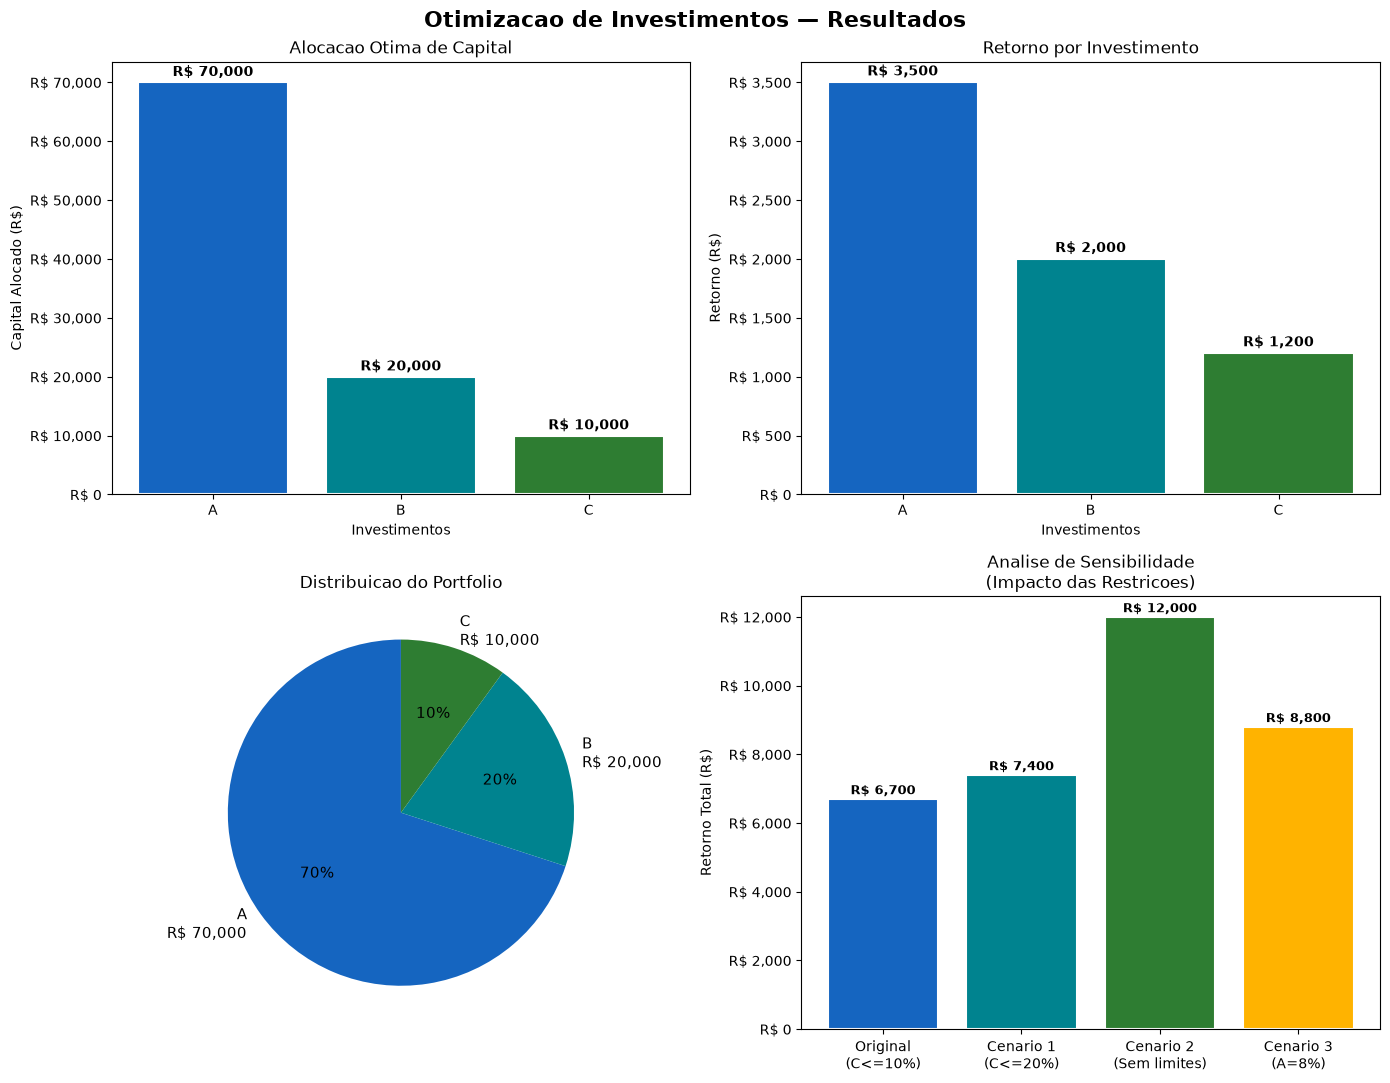


Os graficos mostram:
  1. A maior parte do capital fica em A (70%), mesmo com menor retorno
  2. B e C contribuem proporcionalmente mais para o retorno
  3. Relaxar restricoes aumenta significativamente o retorno potencial
  4. Melhorar o retorno de A tem grande impacto no resultado final


In [13]:
# Configurar estilo
plt.style.use('default')
colors_plot = ['#1565C0', '#00838F', '#2E7D32']

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Otimizacao de Investimentos — Resultados', fontsize=16, fontweight='bold', y=0.98)

# Grafico 1: Alocacao otima
bars1 = ax1.bar(investimentos, alocacoes_otimizadas, color=colors_plot, edgecolor='white', linewidth=1.5)
ax1.set_xlabel('Investimentos')
ax1.set_ylabel('Capital Alocado (R$)')
ax1.set_title('Alocacao Otima de Capital')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))
for bar, val in zip(bars1, alocacoes_otimizadas):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'R$ {val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Grafico 2: Retornos
bars2 = ax2.bar(investimentos, retornos_otimizados, color=colors_plot, edgecolor='white', linewidth=1.5)
ax2.set_xlabel('Investimentos')
ax2.set_ylabel('Retorno (R$)')
ax2.set_title('Retorno por Investimento')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))
for bar, val in zip(bars2, retornos_otimizados):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'R$ {val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Grafico 3: Pizza da alocacao
ax3.pie(alocacoes_otimizadas, labels=[f'{inv}\nR$ {val:,.0f}' for inv, val in zip(investimentos, alocacoes_otimizadas)],
        colors=colors_plot, autopct='%1.0f%%', startangle=90, textprops={'fontsize': 11})
ax3.set_title('Distribuicao do Portfolio')

# Grafico 4: Analise de sensibilidade
cenarios = ['Original\n(C<=10%)', 'Cenario 1\n(C<=20%)', 'Cenario 2\n(Sem limites)', 'Cenario 3\n(A=8%)']
retornos_cenarios = [retorno_total_otimizado, cenario1['Retorno_Total'], cenario2['Retorno_Total'], cenario3['Retorno_Total']]
bars4 = ax4.bar(cenarios, retornos_cenarios, color=['#1565C0', '#00838F', '#2E7D32', '#FFB300'],
                edgecolor='white', linewidth=1.5)
ax4.set_ylabel('Retorno Total (R$)')
ax4.set_title('Analise de Sensibilidade\n(Impacto das Restricoes)')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))
for bar, val in zip(bars4, retornos_cenarios):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'R$ {val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nOs graficos mostram:")
print("  1. A maior parte do capital fica em A (70%), mesmo com menor retorno")
print("  2. B e C contribuem proporcionalmente mais para o retorno")
print("  3. Relaxar restricoes aumenta significativamente o retorno potencial")
print("  4. Melhorar o retorno de A tem grande impacto no resultado final")

## 7. Conclusões

### O que aprendemos hoje:

1. **Otimização dá certeza, intuição dá palpite**: Neste problema simples, a intuição acertou — mas a otimização nos *garante* que é o melhor possível. Em problemas complexos, só a otimização funciona.

2. **Restrições são fundamentais**: Elas representam limitações reais (risco, regulamentação, recursos) que moldam completamente a solução.

3. **Diversificação forçada**: As restrições de risco obrigam a diversificação, mesmo quando um ativo tem retorno superior.

4. **Análise de sensibilidade é valiosa**: Mostra como mudanças nos parâmetros afetam a solução, permitindo avaliar cenários e tomar decisões informadas.

5. **Ferramentas acessíveis**: Frameworks como Pyomo + solvers como HiGHS (instalável via pip, sem dependências externas) permitem resolver problemas de otimização de forma gratuita e reprodutível.

### Conceitos-chave:
- **Variáveis de decisão**: O que podemos controlar (alocação de capital)
- **Função objetivo**: O que queremos otimizar (maximizar retorno)
- **Restrições**: Limitações que devemos respeitar (limites de risco)
- **Solução ótima**: A melhor decisão possível dentro das limitações
- **Análise de sensibilidade**: Como a solução muda com os parâmetros